# Comparing Multiple Targets with `Sample`

When planning observations, it is common to ask: *how does the required exposure time change with redshift?* or *how much data will I accumulate over a survey?*

The `slicersim.sample.Sample` class lets you manage a collection of targets together and answer these questions efficiently.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import slicersim
from slicersim.sample import Sample

***
## 1. Build a sample of type Ia supernovae

`Sample.from_sneia()` creates a collection of `LazuliSupernova` objects at the given redshifts.
The spectrograph field (`"narrow"` or `"wide"`) is automatically selected based on the redshift:
`"narrow"` up to z=0.8, `"wide"` beyond.

In [2]:
# Create a sample of 8 SN Ia spanning z=0.2 to z=1.4
redshifts = np.linspace(0.2, 1.4, 8)
sample = Sample.from_sneia(redshifts)
print(f"Sample has {sample.ntargets} targets")

Sample has 8 targets


You can access individual targets by index:

In [3]:
# Inspect one target
t0 = sample.get_target(0)
print(f"First target: z = {t0.get_properties('redshift'):.2f}, field = {t0.get_spectrograph_field()}")

First target: z = 0.20, field = ('narrow', {'spatial_shape': [58, 58], 'spatial_scale': 0.04})


***
## 2. Set up the sample to reach a given SNR

`setup_to_snr()` configures the detector readout mode of each target so that the requested
mean SNR per resolution element is reached in the given wavelength window (here rest-frame).

In [4]:
%%time
# Aim for SNR=10 per resolution element in rest-frame 4000-7000 A
_ = sample.setup_to_snr(
    snr=10,
    per_resolution=True,
    lbda_range=[4000, 7000],
    frame="rest",
)

CPU times: user 2.85 s, sys: 1.7 s, total: 4.55 s
Wall time: 6.48 s


***
## 3. Summary statistics

`get_summary_stats()` returns a DataFrame with the exposure time, the data volume and the
detector readout configuration of each target.

In [5]:
stats = sample.get_summary_stats()
stats.index = np.round(redshifts, 2)
stats.index.name = "redshift"
stats

,volume,exptime,nramps,ngroups,nframes_per_group,ndrops
redshift,,,,,,
0.20,0.436208,147.16,1,13,4,0
0.37,0.905970,305.64,1,27,4,0
0.54,0.771752,520.72,1,23,8,0
0.71,1.073742,724.48,1,32,8,0
0.89,1.308623,882.96,1,39,8,0
1.06,2.113929,1426.32,1,63,8,0
1.23,3.623879,2445.12,2,54,8,0
1.40,4.294967,2897.92,2,64,8,0


Notice how the readout mode (`ngroups`, `nframes_per_group`) and the number of ramps
(`nramps`) increase with redshift, as the source gets fainter and longer exposures are needed.

***
## 4. Exposure time vs. redshift

The cost of observing a SN Ia grows steeply with redshift.

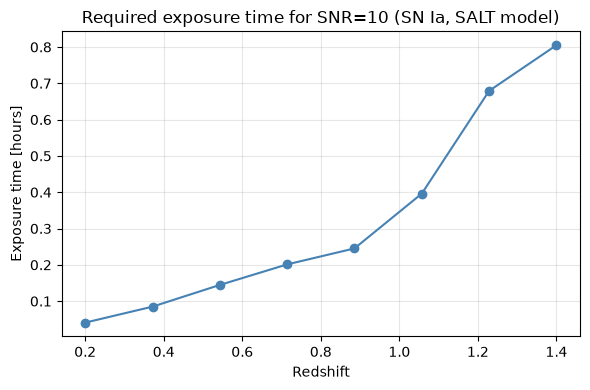

In [6]:
exptimes_h = sample.get_exposure_time(units="hour")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(redshifts, exptimes_h, "o-", color="steelblue")
ax.set_xlabel("Redshift")
ax.set_ylabel("Exposure time [hours]")
ax.set_title("Required exposure time for SNR=10 (SN Ia, SALT model)")
ax.grid(alpha=0.3)
plt.tight_layout()

***
## 5. Data volume vs. redshift

Higher-redshift targets require longer or more ramps, which increases the raw data volume of
each observation.

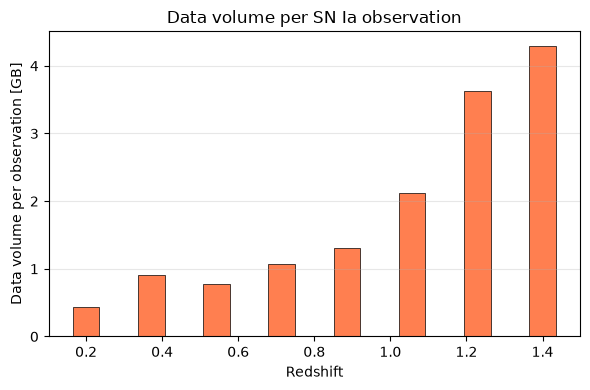

In [7]:
data_volumes = sample.get_data_volume(units="GB")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(redshifts, data_volumes, width=0.07, color="coral", edgecolor="k", linewidth=0.5)
ax.set_xlabel("Redshift")
ax.set_ylabel("Data volume per observation [GB]")
ax.set_title("Data volume per SN Ia observation")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

***
## 6. Survey duration estimate

`get_total_surveyduration()` scales the exposure times of the sample to estimate how long a
larger survey would take. It assumes that the survey targets follow the same distribution as
the sample. By default, it assumes a survey of 8000 SN Ia and that 40% of the mission time is
spent on it (`fraction_survey=0.4`).

In [8]:
# How many years would a 2000-target survey take with 40% of the mission time?
duration_yr = sample.get_total_surveyduration(sample_size=2000, fraction_survey=0.4, units="yr")
print(f"Estimated survey duration: {duration_yr:.2f} years")

Estimated survey duration: 0.19 years


***
## 7. Visualizing spectra across the sample

Loop over targets to retrieve and plot individual spectra.

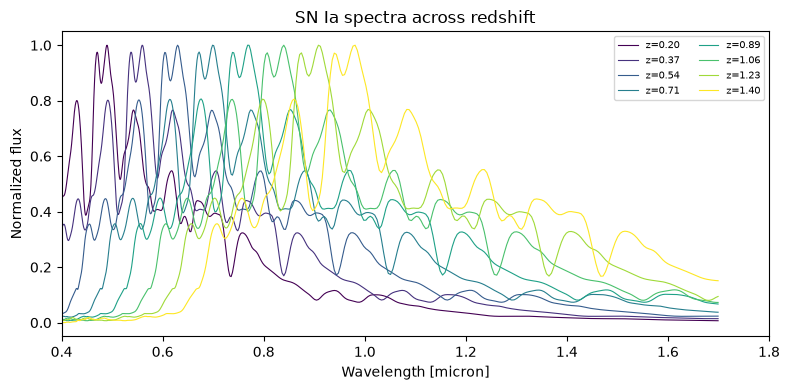

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

cmap = plt.cm.viridis
for i, target in enumerate(sample.targets):
    lbda, flux, variance = target.get_spectrum(unit="flambda", incl_error=False)
    color = cmap(i / (sample.ntargets - 1))
    z = target.get_properties("redshift")
    ax.plot(lbda / 1e4, flux / flux.max(), lw=0.8, color=color, label=f"z={z:.2f}")

ax.set_xlabel("Wavelength [micron]")
ax.set_ylabel("Normalized flux")
ax.set_title("SN Ia spectra across redshift")
ax.legend(fontsize=7, ncol=2)
ax.set_xlim(0.4, 1.8)
plt.tight_layout()

As expected, the SN Ia spectral features shift to longer wavelengths at higher redshifts.